In [15]:
import pandas as pd
import numpy as np
from warnings import filterwarnings
filterwarnings('ignore',category=UserWarning,module='matplotlib')

import seaborn as sns
import matplotlib.pyplot as plt
import mplcyberpunk as cp
plt.style.use('cyberpunk')

In [3]:
df = pd.read_csv('ai_student_impact_dataset (1).csv')

In [4]:
df.head()

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium


In [5]:
df.shape

(50000, 16)

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.ndim

2

In [8]:
df.isna().mean() * 100

Student_ID                    0.0
Major_Category                0.0
Year_of_Study                 0.0
Pre_Semester_GPA              0.0
Weekly_GenAI_Hours            0.0
Primary_Use_Case              0.0
Prompt_Engineering_Skill      0.0
Tool_Diversity                0.0
Paid_Subscription             0.0
Traditional_Study_Hours       0.0
Perceived_AI_Dependency       0.0
Institutional_Policy          0.0
Anxiety_Level_During_Exams    0.0
Post_Semester_GPA             0.0
Skill_Retention_Score         0.0
Burnout_Risk_Level            0.0
dtype: float64

In [18]:
df.sample(4)

,student_id,major_category,year_of_study,pre_semester_gpa,weekly_genai_hours,primary_use_case,prompt_engineering_skill,tool_diversity,paid_subscription,traditional_study_hours,perceived_ai_dependency,institutional_policy,anxiety_level_during_exams,post_semester_gpa,skill_retention_score,burnout_risk_level
3526,103527,Medical,Junior,3.487,9.91,Copywriting/Drafting,Intermediate,1,True,5.31,2,Allowed_With_Citation,1,3.502,91.52,Medium
7488,107489,Business,Junior,3.185,3.37,Ideation,Intermediate,4,False,18.01,4,Actively_Encouraged,1,3.518,64.79,Low
34173,134174,Arts,Senior,2.667,4.54,Copywriting/Drafting,Beginner,2,False,13.85,4,Strict_Ban,6,2.952,71.38,Medium
18599,118600,STEM,Graduate,3.585,9.92,Copywriting/Drafting,Intermediate,1,False,4.76,1,Allowed_With_Citation,5,3.697,92.04,Medium


In [42]:
from scipy.stats import pearsonr

corr,p = pearsonr(df['paid_subscription'],df['traditional_study_hours'])
print(corr)
print(p)

-0.035328721755777906
2.7443829163365305e-15


In [17]:
df.columns = df.columns.str.lower()

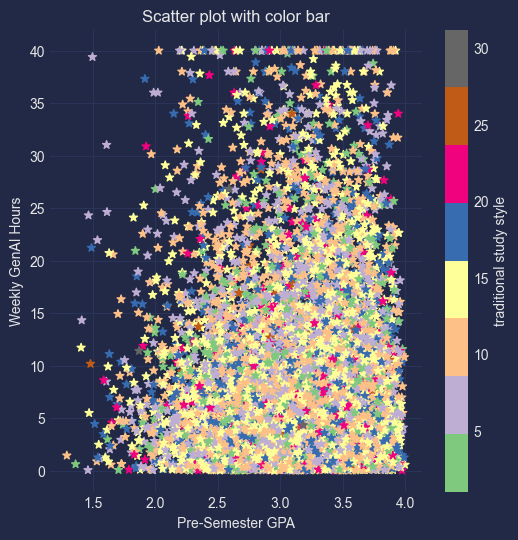

In [38]:
fig,ax = plt.subplots(figsize=(6,6))

scatter = ax.scatter(df['pre_semester_gpa'].sample(10000),
            df['weekly_genai_hours'].sample(10000),
            c=df['traditional_study_hours'].sample(10000),
            cmap='Accent',
            marker='*')
fig.colorbar(scatter,ax =ax,label='traditional study style')            

ax.set_xlabel('Pre-Semester GPA')
ax.set_ylabel('Weekly GenAI Hours')
ax.set_title('Scatter plot with color bar')
plt.show()

In [46]:
import numpy as np
import pandas as pd
from feature_engine.encoding import MeanEncoder, RareLabelEncoder
from feature_engine.outliers import Winsorizer
from feature_engine.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# 1. Dummy Data banana (Pandas DataFrame)
data = {
    "city": [
        "Mumbai",
        "Mumbai",
        "Delhi",
        "Delhi",
        "Goa",
        "Mumbai",
        "Delhi",
        "Patna",
    ],  # 'Goa' aur 'Patna' rare hain
    "age": [23, 25, 29, 31, 22, 120, 26, 28],  # 120 ek outlier hai!
    "churn": [1, 1, 0, 0, 1, 0, 0, 1],  # Target Variable
}
df = pd.DataFrame(data)
X = df[["city", "age"]]
y = df["churn"]

# 2. Feature-engine Pipeline taiyar karna
# Note: Hum 'feature_engine.pipeline.Pipeline' use kar rahe hain
engine_pipe = Pipeline(
    [
        # Step 1: Kam दिखने wali categories ko 'Rare' naam de do
        (
            "rare_encoder",
            RareLabelEncoder(tol=0.20, n_categories=2, variables=["city"]),
        ),
        # Step 2: Categorical column ko Mean Encoding mein badlo (isko 'y' chahiye hota hai)
        ("mean_encoder", MeanEncoder(variables=["city"])),
        # Step 3: Age ke outliers ko 95th percentile par cap (Winsorize) karo
        (
            "outlier_capper",
            Winsorizer(capping_method="gaussian", tail="right", fold=2),
        ),
        # Step 4: Final Sklearn Model
        ("model", LogisticRegression()),
    ]
)

# 3. Pipeline ko fit aur train karna
engine_pipe.fit(X, y)

# 4. Sirf transformation dekhne ke liye (Model step se pehle tak)
# Feature-engine direct Pandas DataFrame return karta hai!
transformed_df = engine_pipe[:-1].transform(X)

print("--- Transformed Pandas DataFrame ---")
print(transformed_df)

--- Transformed Pandas DataFrame ---
       city         age
0  0.666667   23.000000
1  0.666667   25.000000
2  0.000000   29.000000
3  0.000000   31.000000
4  1.000000   22.000000
5  0.666667  100.241465
6  0.000000   26.000000
7  1.000000   28.000000


In [47]:
import duckdb

In [48]:
df1 =duckdb.read_csv("ai_student_impact_dataset (1).csv")

In [49]:
df1

┌────────────┬────────────────┬───────────────┬──────────────────┬────────────────────┬───────────────────────────┬──────────────────────────┬────────────────┬───────────────────┬─────────────────────────┬─────────────────────────┬───────────────────────┬────────────────────────────┬───────────────────┬───────────────────────┬────────────────────┐
│ Student_ID │ Major_Category │ Year_of_Study │ Pre_Semester_GPA │ Weekly_GenAI_Hours │     Primary_Use_Case      │ Prompt_Engineering_Skill │ Tool_Diversity │ Paid_Subscription │ Traditional_Study_Hours │ Perceived_AI_Dependency │ Institutional_Policy  │ Anxiety_Level_During_Exams │ Post_Semester_GPA │ Skill_Retention_Score │ Burnout_Risk_Level │
│   int64    │    varchar     │    varchar    │      double      │       double       │          varchar          │         varchar          │     int64      │      boolean      │         double          │          int64          │        varchar        │           int64            │      double    

In [51]:
import duckdb
duckdb.sql("select * from df1 where Year_of_Study in('Senior','Junior')")

┌────────────┬────────────────┬───────────────┬──────────────────┬────────────────────┬───────────────────────────┬──────────────────────────┬────────────────┬───────────────────┬─────────────────────────┬─────────────────────────┬───────────────────────┬────────────────────────────┬───────────────────┬───────────────────────┬────────────────────┐
│ Student_ID │ Major_Category │ Year_of_Study │ Pre_Semester_GPA │ Weekly_GenAI_Hours │     Primary_Use_Case      │ Prompt_Engineering_Skill │ Tool_Diversity │ Paid_Subscription │ Traditional_Study_Hours │ Perceived_AI_Dependency │ Institutional_Policy  │ Anxiety_Level_During_Exams │ Post_Semester_GPA │ Skill_Retention_Score │ Burnout_Risk_Level │
│   int64    │    varchar     │    varchar    │      double      │       double       │          varchar          │         varchar          │     int64      │      boolean      │         double          │          int64          │        varchar        │           int64            │      double    